# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ShardhaBatra/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*



### Research Question

Can historical search and engagement signals be used to identify content pages that are likely to experience future performance decline?

### Decision Supported

This work supports content teams in deciding which pages should be reviewed first for possible SEO or content improvement.

The system is intended as decision support, not as proof that updating a page will cause its performance to improve.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*



### Data Release

This project uses the FlyRank ML Internship warehouse release available on Hugging Face.

### Table Used

The main table used is `fact_content_daily_performance`, which contains daily search and engagement performance for content pages.

Each row represents the daily performance of one content page for one client on one date.

### Date Window

The analysis uses data from March 2026 through June 2026.

March 2026 is used for feature development and earlier periods are available for historical modeling. Later observations are used to construct and evaluate future outcomes using a time-aware design. June 2026 is treated as the final outcome/test period rather than being used to develop the label logic.

### Fields Excluded

Client and content IDs are used only for joining, grouping, and identifying rows, not as model features.

Future-window information, label-derived fields such as `trend_direction` and `trend_pct`, and product decision flags are excluded because they would reveal information about the outcome or introduce data leakage.

No client names, domains, URLs, private queries, credentials, or raw exports are used.

In [1]:
# Load the March 2026 warehouse data

from google.colab import userdata
from huggingface_hub import login
from datasets import load_dataset

login(userdata.get("HF_TOKEN"))

ds = load_dataset(
    "FlyRank/internship-warehouse",
    data_files="fact_content_daily_performance/month=2026-03/data_0.parquet",
    split="train",
    token=userdata.get("HF_TOKEN")
)

df = ds.to_pandas()

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Start date:", df["report_date"].min())
print("End date:", df["report_date"].max())

Rows: 9841378
Columns: 30
Start date: 2026-03-01
End date: 2026-03-31


Data verification

The March 2026 warehouse data contains 9,841,378 daily content-performance rows covering March 1–31, 2026. The analysis uses March as the feature window and April as the first future outcome window. Content pages must be present in both months so that the future decline label can be calculated consistently.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [2]:
# Check the available warehouse months

months = [
    "2026-03",
    "2026-04",
    "2026-05",
    "2026-06"
]

print("Months available for capstone development:")
for month in months:
    print(month)

Months available for capstone development:
2026-03
2026-04
2026-05
2026-06


In [3]:
# Load April 2026 data

ds_april = load_dataset(
    "FlyRank/internship-warehouse",
    data_files="fact_content_daily_performance/month=2026-04/data_0.parquet",
    split="train",
    token=userdata.get("HF_TOKEN")
)

df_april = ds_april.to_pandas()

print("April rows:", len(df_april))
print("April start:", df_april["report_date"].min())
print("April end:", df_april["report_date"].max())

April rows: 10424730
April start: 2026-04-01
April end: 2026-04-30


In [4]:
# Check how many content pages appear in both March and April

march_content = set(df["content_hash_id"].unique())
april_content = set(df_april["content_hash_id"].unique())

common_content = march_content.intersection(april_content)

print("March unique content:", len(march_content))
print("April unique content:", len(april_content))
print("Content present in both months:", len(common_content))

March unique content: 331437
April unique content: 362172
Content present in both months: 331436


In [5]:
# Aggregate March performance for each content page

march_summary = (
    df.groupby("content_hash_id")
    .agg(
        march_impressions=("gsc_impressions", "sum"),
        march_clicks=("gsc_clicks", "sum")
    )
    .reset_index()
)

# Aggregate April performance for each content page

april_summary = (
    df_april.groupby("content_hash_id")
    .agg(
        april_impressions=("gsc_impressions", "sum"),
        april_clicks=("gsc_clicks", "sum")
    )
    .reset_index()
)

print("March content:", len(march_summary))
print("April content:", len(april_summary))

March content: 331437
April content: 362172


In [6]:
# Keep only content pages available in both months

comparison = march_summary.merge(
    april_summary,
    on="content_hash_id",
    how="inner"
)

print("Content available in both months:", len(comparison))

comparison.head()

Content available in both months: 331436


,content_hash_id,march_impressions,march_clicks,april_impressions,april_clicks
0,content_000005d4ced12088,86,0,81,0
1,content_00001e488b74b799,0,0,0,0
2,content_00007bd2985b77c3,47,0,48,0
3,content_00008950670cb6b5,0,0,0,0
4,content_0000a348850eb1fc,0,0,0,0


In [7]:
# Calculate percentage change in clicks from March to April
import pandas as pd
comparison["click_change_pct"] = (
    (comparison["april_clicks"] - comparison["march_clicks"])
    / comparison["march_clicks"].replace(0, pd.NA)
) * 100

print(comparison["click_change_pct"].describe())

count     68837.0
unique     3452.0
top        -100.0
freq      21205.0
Name: click_change_pct, dtype: float64


In [8]:
print("Pages with March clicks > 0:",
      (comparison["march_clicks"] > 0).sum())

print("Pages with March clicks = 0:",
      (comparison["march_clicks"] == 0).sum())

Pages with March clicks > 0: 68837
Pages with March clicks = 0: 262599


In [9]:
# Define future decline label

comparison["future_decline"] = (
    (comparison["march_clicks"] > 0) &
    (comparison["click_change_pct"] <= -30)
).astype(int)

print(comparison["future_decline"].value_counts())

future_decline
0    291676
1     39760
Name: count, dtype: int64


In [10]:
print(
    "Future decline rate:",
    round(comparison["future_decline"].mean() * 100, 2),
    "%"
)

Future decline rate: 12.0 %


Label Definition

A page is labeled as future_decline = 1 if its clicks decrease by at least 30% from March to April. This label uses future information only for evaluation and is never used as a model feature.

The decline rate is approximately 12%, meaning the dataset is moderately imbalanced.

Feature Design

The model uses six features calculated only from March data: impressions, clicks, CTR, average search position, GA4 sessions, and scroll events. These features represent search visibility, click performance, search position, and user engagement available before the April outcome window. No April information is used as a model input.

In [11]:
# Build March-only features

features = march_summary.copy()

features = features.rename(columns={
    "march_impressions": "impressions",
    "march_clicks": "clicks"
})

# Add simple March features
features["ctr"] = (
    features["clicks"] /
    features["impressions"].replace(0, pd.NA)
) * 100

# Add the future label
features = features.merge(
    comparison[["content_hash_id", "future_decline"]],
    on="content_hash_id",
    how="inner"
)

print("Feature rows:", len(features))
print("Feature columns:")
print(features.columns.tolist())

features.head()

Feature rows: 331436
Feature columns:
['content_hash_id', 'impressions', 'clicks', 'ctr', 'future_decline']


,content_hash_id,impressions,clicks,ctr,future_decline
0,content_000005d4ced12088,86,0,0.0,0
1,content_00001e488b74b799,0,0,<NA>,0
2,content_00007bd2985b77c3,47,0,0.0,0
3,content_00008950670cb6b5,0,0,<NA>,0
4,content_0000a348850eb1fc,0,0,<NA>,0


In [12]:
# Build additional March-level features

march_features = (
    df
    .groupby("content_hash_id")
    .agg(
        avg_position=("gsc_avg_position", "mean"),
        ga4_sessions=("ga4_sessions", "sum"),
        scroll_events=("scroll_events", "sum")
    )
    .reset_index()
)

print(march_features.shape)
march_features.head()

(331437, 4)


,content_hash_id,avg_position,ga4_sessions,scroll_events
0,content_000005d4ced12088,72.854861,0.0,0.0
1,content_00001e488b74b799,NaN,0.0,0.0
2,content_00007bd2985b77c3,5.269565,0.0,0.0
3,content_00008950670cb6b5,NaN,2.0,1.0
4,content_0000a348850eb1fc,NaN,1.0,1.0


In [13]:
features = features.merge(
    march_features,
    on="content_hash_id",
    how="left"
)

print(features.shape)
print(features.columns.tolist())

(331436, 8)
['content_hash_id', 'impressions', 'clicks', 'ctr', 'future_decline', 'avg_position', 'ga4_sessions', 'scroll_events']


In [ ]:
features.isnull().sum()

Missing Value Handling

CTR and average position are missing for 154,699 of the 331,436 pages because usable GSC information is not available for those pages. For this baseline model, missing CTR and position values are filled with 0 so the model can run on a complete feature matrix. A zero position should not be interpreted as an actual search ranking; it represents unavailable position information and is therefore a limitation of this simple treatment.

In [14]:
# Handle missing values

features["ctr"] = features["ctr"].fillna(0)
features["avg_position"] = features["avg_position"].fillna(0)

print(features.isnull().sum())

content_hash_id    0
impressions        0
clicks             0
ctr                0
future_decline     0
avg_position       0
ga4_sessions       0
scroll_events      0
dtype: int64


/tmp/ipykernel_4558/1683889082.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  features["ctr"] = features["ctr"].fillna(0)


In [15]:
# Separate features and target

X = features[
    [
        "impressions",
        "clicks",
        "ctr",
        "avg_position",
        "ga4_sessions",
        "scroll_events"
    ]
]

y = features["future_decline"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Decline rate:", round(y.mean() * 100, 2), "%")

X shape: (331436, 6)
y shape: (331436,)
Decline rate: 12.0 %


Validation Design

The dataset is split into 80% training and 20% testing data using a fixed random seed and stratification on the future-decline label. Both sets contain approximately the same 12% decline rate. The model is evaluated only on the held-out test set.

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Train decline rate:", round(y_train.mean() * 100, 2), "%")
print("Test decline rate:", round(y_test.mean() * 100, 2), "%")

Training rows: 265148
Test rows: 66288
Train decline rate: 12.0 %
Test decline rate: 12.0 %


The test set contains 66,288 pages, including 7,952 actual future declines.

I use a Random Forest classifier as the first predictive model. It was selected because it can capture non-linear relationships between the search and engagement signals without requiring complex feature transformations. Class balancing is enabled because only 12% of pages are labeled as future declines.

In [17]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=8, n_jobs=-1,
                       random_state=42)

In [18]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [19]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:", round(recall_score(y_test, y_pred), 3))
print("F1:", round(f1_score(y_test, y_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 3))

Precision: 0.582
Recall: 1.0
F1: 0.736
ROC-AUC: 0.966


The Random Forest achieved a precision of 0.582, recall of 1.000, F1 score of 0.736, and ROC-AUC of 0.966 on the held-out test set. The perfect recall means the model identified all observed declines in this test set, while the precision of 0.582 shows that many pages it flagged did not actually decline.

The Week-4 rule is used as the transparent baseline. It scores pages using five hand-written conditions: impressions, clicks, average position, GA4 sessions, and scroll events. A score of 4 or 5 is treated as a positive prediction of future decline for this comparison. The baseline is evaluated on exactly the same test pages and labels as the Random Forest.

In [20]:
# Build Week-4 baseline on the same test set

baseline_test = features.loc[X_test.index].copy()

baseline_test["baseline_score"] = 0

baseline_test.loc[
    baseline_test["impressions"] >= 100,
    "baseline_score"
] += 1

baseline_test.loc[
    baseline_test["clicks"] <= 5,
    "baseline_score"
] += 1

baseline_test.loc[
    baseline_test["avg_position"] >= 20,
    "baseline_score"
] += 1

baseline_test.loc[
    baseline_test["ga4_sessions"] <= 10,
    "baseline_score"
] += 1

baseline_test.loc[
    baseline_test["scroll_events"] <= 5,
    "baseline_score"
] += 1

print(baseline_test["baseline_score"].value_counts().sort_index())

baseline_score
1      735
2     1969
3    45413
4    14539
5     3632
Name: count, dtype: int64


In [21]:
baseline_pred = (
    baseline_test["baseline_score"] >= 4
).astype(int)

print("Baseline positive predictions:", baseline_pred.sum())
print("Actual declines:", y_test.sum())

Baseline positive predictions: 18171
Actual declines: 7952


In [22]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

print("Baseline Precision:",
      round(precision_score(y_test, baseline_pred), 3))

print("Baseline Recall:",
      round(recall_score(y_test, baseline_pred), 3))

print("Baseline F1:",
      round(f1_score(y_test, baseline_pred), 3))

Baseline Precision: 0.241
Baseline Recall: 0.552
Baseline F1: 0.336


The Week-4 baseline achieved a precision of 0.241, recall of 0.552, and F1 score of 0.336. This provides a transparent benchmark for judging whether the predictive model adds value beyond the hand-written rule.

In [23]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print(importance)

         feature  importance
1         clicks    0.390759
2            ctr    0.371519
0    impressions    0.136348
3   avg_position    0.076081
4   ga4_sessions    0.024781
5  scroll_events    0.000512


Feature importance analysis showed that clicks and CTR were the strongest contributors to the model's predictions, while scroll events contributed very little. These results are directional and describe model behavior rather than causal effects.

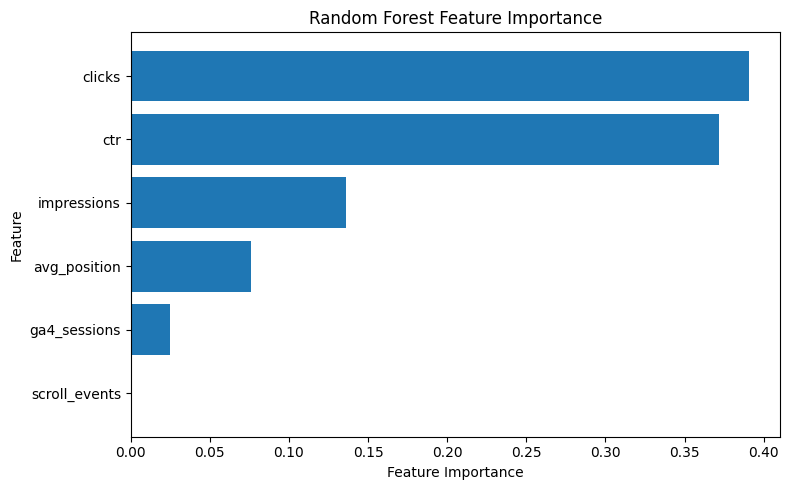

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.barh(
    importance["feature"],
    importance["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    "feature_importance.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [25]:
# Predict decline probability for all March pages

features["decline_probability"] = model.predict_proba(X)[:, 1]

ranked_recommendations = features.sort_values(
    "decline_probability",
    ascending=False
).copy()

ranked_recommendations[
    [
        "content_hash_id",
        "decline_probability",
        "impressions",
        "clicks",
        "ctr",
        "avg_position"
    ]
].head(20)

,content_hash_id,decline_probability,impressions,clicks,ctr,avg_position
156721,content_79470c0b5f64d6f6,0.993186,1,1,100.0,0.0
90007,content_45c3aaf2235cfb8f,0.993186,1,1,100.0,0.0
274137,content_d3f982a535c1f35f,0.993186,1,1,100.0,0.0
247430,content_bf583de6bf5dded7,0.993186,1,1,100.0,0.0
209688,content_a20e9f4fa7d94502,0.992896,2,1,50.0,9.0
210538,content_a2af57d5e16fef83,0.992876,1,1,100.0,8.0
154433,content_7782cd9c7533cbe1,0.992862,1,1,100.0,10.0
72036,content_37ea37e555b4040d,0.992857,1,1,100.0,9.0
162333,content_7d9c2bb43460c94d,0.992857,1,1,100.0,9.0
49180,content_263bad6547f5b1d6,0.992836,2,1,50.0,8.0


In [26]:
def recommendation(probability):
    if probability >= 0.80:
        return "Review urgently"
    elif probability >= 0.50:
        return "Review"
    else:
        return "Monitor"

ranked_recommendations["action"] = (
    ranked_recommendations["decline_probability"]
    .apply(recommendation)
)

ranked_recommendations.head(20)

,content_hash_id,impressions,clicks,ctr,future_decline,avg_position,ga4_sessions,scroll_events,decline_probability,action
156721,content_79470c0b5f64d6f6,1,1,100.0,1,0.0,1.0,1.0,0.993186,Review urgently
90007,content_45c3aaf2235cfb8f,1,1,100.0,1,0.0,1.0,1.0,0.993186,Review urgently
274137,content_d3f982a535c1f35f,1,1,100.0,1,0.0,1.0,1.0,0.993186,Review urgently
247430,content_bf583de6bf5dded7,1,1,100.0,1,0.0,1.0,1.0,0.993186,Review urgently
209688,content_a20e9f4fa7d94502,2,1,50.0,1,9.0,0.0,0.0,0.992896,Review urgently
210538,content_a2af57d5e16fef83,1,1,100.0,1,8.0,0.0,0.0,0.992876,Review urgently
154433,content_7782cd9c7533cbe1,1,1,100.0,1,10.0,0.0,0.0,0.992862,Review urgently
72036,content_37ea37e555b4040d,1,1,100.0,1,9.0,1.0,0.0,0.992857,Review urgently
162333,content_7d9c2bb43460c94d,1,1,100.0,1,9.0,1.0,0.0,0.992857,Review urgently
49180,content_263bad6547f5b1d6,2,1,50.0,1,8.0,0.0,0.0,0.992836,Review urgently


In [27]:
may_ds = load_dataset(
    "FlyRank/internship-warehouse",
    data_files="fact_content_daily_performance/month=2026-05/data_0.parquet",
    split="train",
    token=userdata.get("HF_TOKEN")
)

may_df = may_ds.to_pandas()

print("May rows:", len(may_df))
print("May start:", may_df["report_date"].min())
print("May end:", may_df["report_date"].max())

May rows: 11687376
May start: 2026-05-01
May end: 2026-05-31


In [28]:
april_ds = load_dataset(
    "FlyRank/internship-warehouse",
    data_files="fact_content_daily_performance/month=2026-04/data_0.parquet",
    split="train",
    token=userdata.get("HF_TOKEN")
)

april_df = april_ds.to_pandas()

print("April rows:", len(april_df))
print("April start:", april_df["report_date"].min())
print("April end:", april_df["report_date"].max())

April rows: 10424730
April start: 2026-04-01
April end: 2026-04-30


In [29]:
april_features = (
    april_df
    .groupby("content_hash_id")
    .agg(
        impressions=("gsc_impressions", "sum"),
        clicks=("gsc_clicks", "sum"),
        avg_position=("gsc_avg_position", "mean"),
        ga4_sessions=("ga4_sessions", "sum"),
        scroll_events=("scroll_events", "sum")
    )
    .reset_index()
)

april_features["ctr"] = (
    april_features["clicks"] /
    april_features["impressions"].replace(0, pd.NA)
) * 100

print("April feature rows:", len(april_features))

April feature rows: 362172


In [30]:
may_features = (
    may_df
    .groupby("content_hash_id")
    .agg(
        may_impressions=("gsc_impressions", "sum"),
        may_clicks=("gsc_clicks", "sum")
    )
    .reset_index()
)

print("May content rows:", len(may_features))

May content rows: 389153


In [31]:
comparison_apr_may = april_features.merge(
    may_features,
    on="content_hash_id",
    how="inner"
)

print("Content available in both April and May:",
      len(comparison_apr_may))

comparison_apr_may.head()


Content available in both April and May: 362172


,content_hash_id,impressions,clicks,avg_position,ga4_sessions,scroll_events,ctr,may_impressions,may_clicks
0,content_000005d4ced12088,81,0,82.395602,0.0,0.0,0.0,81,0
1,content_00001e488b74b799,0,0,NaN,0.0,0.0,<NA>,0,0
2,content_00007bd2985b77c3,48,0,3.944203,0.0,0.0,0.0,14,0
3,content_00008950670cb6b5,0,0,NaN,0.0,0.0,<NA>,0,0
4,content_0000a348850eb1fc,0,0,NaN,0.0,0.0,<NA>,1,0


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## 5. Limitations

*What this work cannot claim.*

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.